In [44]:
import copy
import inspect
import json
import math
import pickle
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "training_data"

sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)
print("torch        =", torch.__version__)
print("cuda         =", torch.cuda.is_available())

PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data
torch        = 2.8.0+cu128
cuda         = True


In [45]:
# Data and target settings
DATASET_NAME = "mean_curvature_smooth"
TARGET_INDICES = [0]
TARGET_INDEX_FOR_PLOTS = 0
USE_GLOBAL_FEATURES = True

# Filtering and preprocessing settings
MISSING_COMPLEXITY_GROUP = {
    "dataset": "20251201",
    "timepoint": "day4p5",
    "fill_value": 2.1,
}
SPHERICITY_MAX = 0.92
SPHERICAL_MARKER_DIVERSITY_MIN = 0.5
COMPLEXITY_MIN = 2.0
INTERPOLATE_TARGET_OUTLIERS = True
OUTLIER_CLIP_QUANTILES = (0.005, 0.995)

# Split and reference-organoid settings
VAL_FRAC = 0.2
SPLIT_SEED = None
FORCED_VAL_KEYS = {
    ("20251201", "day4p5_B03_144"),
}
REFERENCE_VIEW = dict(azim=-135, elev=55)

# Feature-subset experiment settings
FEATURE_VARIANTS = {
    "all_markers": None,
    "LGR5_only": ["LGR5"],
    "AldoB_only": ["AldoB"],
    "LGR5_Lysozyme_Serotonin_Chroma": ["LGR5", "Lysozyme", "Serotonin", "Chroma"],
}
FEATURE_VARIANT_LABELS = {
    "all_markers": "All markers",
    "LGR5_only": "LGR5 only",
    "AldoB_only": "AldoB only",
    "LGR5_Lysozyme_Serotonin_Chroma": "LGR5 + Lysozyme + Serotonin + Chroma",
}
DEPTHS = [0, 1, 2, 3, 4]

# Model settings
HIDDEN_DIM = 2 * 64
DROPOUT = 0.1
NORM = "batch"
RESIDUAL = True

# Training settings
LR = 3e-4
BATCH_SIZE = 128
MAX_EPOCHS = 2000
PATIENCE = 30
NUM_WORKERS = 4
PREDICT_BATCH_SIZE = 128
EDGE_LOSS_WEIGHT = 0.20
EDGE_LOSS_PARAMS = {
    "weighted": False,
    "alpha": 2.0,
    "normalize_by": "graph_std",
    "clip_weight": 4.0,
}

# Experiment output settings
EXPERIMENT_GROUP = "marker_subset_depth_comparison"
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_NAME = f"run_{RUN_TIMESTAMP}"
SAVE_DIR = PROJECT_ROOT / "results_experiments" / EXPERIMENT_GROUP / RUN_NAME
FIGURES_DIR = SAVE_DIR / "figures"

# Marker Subset Depth Comparison

This experiment trains depth-scanned GIN models on the same train/validation organoids while varying only the available fate-marker columns.

In [46]:
def _safe_filename(name):
    text = str(name).strip().replace("/", "_")
    chars = [ch if (ch.isalnum() or ch in "._-") else "_" for ch in text]
    cleaned = "".join(chars).strip("._-")
    while "__" in cleaned:
        cleaned = cleaned.replace("__", "_")
    return cleaned or "figure"


def ensure_figure_dir():
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    return FIGURES_DIR


def save_mpl_figure(fig, name, *, close=False):
    path = ensure_figure_dir() / f"{_safe_filename(name)}.pdf"
    fig.savefig(path, bbox_inches="tight", transparent=True)
    print(f"Saved figure -> {path}")
    if close:
        plt.close(fig)
    return path


def save_plotly_figure(fig, name, *, scale=2):
    path = ensure_figure_dir() / f"{_safe_filename(name)}.png"
    try:
        fig.write_image(str(path), scale=scale)
        print(f"Saved Plotly figure -> {path}")
    except Exception as exc:
        print(f"Could not save Plotly figure as PNG at {path}: {exc}")
    return path


def _jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): _jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [_jsonable(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, torch.dtype):
        return str(obj)
    if isinstance(obj, np.dtype):
        return str(obj)
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


def save_joint_experiment(save_dir, config, results_by_experiment, notes=None):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    with open(save_dir / "config.json", "w") as f:
        json.dump(_jsonable(config), f, indent=2)

    with open(save_dir / "results.pkl", "wb") as f:
        pickle.dump(results_by_experiment, f)

    meta = {
        "timestamp": datetime.now().isoformat(),
        "notes": notes,
        "experiments": list(results_by_experiment.keys()),
    }
    with open(save_dir / "meta.json", "w") as f:
        json.dump(_jsonable(meta), f, indent=2)

    print(f"Saved joint experiment -> {save_dir}")

## Load Data

In [47]:
from src.data.io import load_graph_dataset_from_dir, select_graph_targets
from src.data.metadata import (
    attach_metadata_to_graphs,
    load_aux_metadata_for_dir,
    load_marker_names_from_dir,
    print_graph_and_metadata_fields,
)

data_dir = DATA_ROOT / DATASET_NAME
graphs = load_graph_dataset_from_dir(str(data_dir))
print(f"Loaded {len(graphs)} organoids.")
if graphs:
    print("Raw y shape:", tuple(graphs[0].y.shape))

meta = load_aux_metadata_for_dir(str(data_dir))
attached = attach_metadata_to_graphs(graphs, meta, exclude_keys=None)
print(f"Attached metadata to {attached}/{len(graphs)} graphs.")

graphs = select_graph_targets(graphs, target_indices=TARGET_INDICES, inplace=False)
if graphs:
    print("Selected y shape:", tuple(graphs[0].y.shape))

marker_names = load_marker_names_from_dir(str(data_dir))
if marker_names is None:
    n_markers = int(graphs[0].x.size(1)) if graphs else 0
    marker_names = [f"marker_{i}" for i in range(n_markers)]
print(f"Loaded {len(marker_names)} markers:", marker_names)

print_graph_and_metadata_fields(graphs)

Loaded 1134 graphs; skipped 0.
Loaded 1134 organoids.
Raw y shape: (265, 2)
Attached metadata to 1134/1134 graphs.
Selected y shape: (265,)
Loaded 7 markers: ['Agr2', 'AldoB', 'Chroma', 'KI67', 'LGR5', 'Lysozyme', 'Serotonin']
Graph fields:
  - _edge_attr_cls
  - _store
  - _tensor_attr_cls

Metadata fields (g.meta):
  - cell_patch_area
  - complexity
  - d_crypts_graph
  - d_crypts_mesh_shape
  - dataset
  - deleted_node_ids
  - graph_path
  - kept_node_ids
  - label_uid
  - mean_gaussian_curvature
  - mean_mean_curvature
  - mesh_path
  - new_to_old_index
  - num_deleted_nodes
  - num_nodes
  - old_to_new_index
  - organoid_id
  - original_num_nodes
  - proj_vertex_ids
  - segmentation_path
  - timepoint
  - total_curvature_discrete
  - total_mean_curvature_discrete
  - total_surface_area
  - total_volume
  - voronoi_vertex_owner
  - y_columns


## Filter And Preprocess

In [48]:
from src.data.metadata import fill_missing_metadata_for_group
from src.data.filters import (
    filter_graphs_by_marker_diversity,
    filter_graphs_by_numeric_metadata,
    filter_graphs_by_sphericity,
)
from src.data.preprocessing import interpolate_target_outliers_from_neighbors

graphs = fill_missing_metadata_for_group(
    graphs,
    field="complexity",
    fill_value=MISSING_COMPLEXITY_GROUP["fill_value"],
    dataset=MISSING_COMPLEXITY_GROUP["dataset"],
    timepoint=MISSING_COMPLEXITY_GROUP["timepoint"],
)

graphs, g_spherical = filter_graphs_by_sphericity(
    graphs,
    max_sphericity=SPHERICITY_MAX,
    print_summary=True,
    return_rejected=True,
)

g_spherical = filter_graphs_by_marker_diversity(
    g_spherical,
    min_score=SPHERICAL_MARKER_DIVERSITY_MIN,
    print_summary=True,
)

graphs = filter_graphs_by_numeric_metadata(
    graphs,
    key="complexity",
    min_value=COMPLEXITY_MIN,
    allow_missing=False,
    inplace=False,
    print_summary=True,
)

graphs = graphs + g_spherical
print(f"After filtering and spherical rescue: {len(graphs)} organoids.")

if INTERPOLATE_TARGET_OUTLIERS:
    graphs, outlier_info = interpolate_target_outliers_from_neighbors(
        graphs,
        target_indices=None,
        clip_quantiles=OUTLIER_CLIP_QUANTILES,
    )
else:
    outlier_info = None

filter_graphs_by_sphericity(max_sphericity=0.92): kept 819 / 1134 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                244    342    0.713
20250929         day4p5               89    104    0.856
20250929         day4p5-more         290    411    0.706
20251201         day4p5              196    277    0.708
filter_graphs_by_marker_diversity(min_score=0.5, top_k=None): kept 93 / 315 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                 37     98    0.378
20250929         day4p5                9     15    0.600
20250929         day4p5-more          27    121    0.223
20251201         day4p5               20     81    0.247
filter_graphs_by_numeric_metadata(key='complexity', min_value=2.0, max_value=None): kept 712 / 819 graphs

dataset          timepoint          kept  total

In [49]:
from src.data.metadata import add_log_metadata_features, promote_metadata_to_graph_tensors

field_specs = [
    {
        "meta_keys": [
            "log_surface_area",
            "log_volume",
            "log_volume_over_area",
            "log_num_cells",
        ],
        "attr_name": "global_feat",
        "kind": "graph_vector",
        "dtype": torch.float32,
    },
]

if USE_GLOBAL_FEATURES:
    graphs = add_log_metadata_features(graphs, inplace=False)
    graphs = promote_metadata_to_graph_tensors(graphs, field_specs, inplace=False)
    print("Promoted metadata fields to graph tensor attributes.")
else:
    print("Global features disabled; no global_feat attribute was attached.")

Promoted metadata fields to graph tensor attributes.


## Shared Split And Feature Variants

In [50]:
from src.data.splits import graph_metadata_key, train_val_split_graphs
from src.data.metadata import infer_global_dim, snapshot_graph_metadata, strip_graph_metadata
from src.data.target_transforms import AsinhStandardizeTransform, standardize_graph_global_features

g_train, g_val, split_info = train_val_split_graphs(
    graphs,
    val_frac=VAL_FRAC,
    seed=SPLIT_SEED,
    force_val_keys=FORCED_VAL_KEYS,
    key_fn=graph_metadata_key,
)
print(f"Split -> train: {len(g_train)} | val: {len(g_val)}")

train_meta_lookup = snapshot_graph_metadata(g_train)
val_meta_lookup = snapshot_graph_metadata(g_val)

g_train = strip_graph_metadata(g_train, inplace=False)
g_val = strip_graph_metadata(g_val, inplace=False)

target_transform = AsinhStandardizeTransform(robust=True).fit(g_train)
target_transform.transform_graphs(g_train)
target_transform.transform_graphs(g_val)

center_global, scale_global = None, None
if USE_GLOBAL_FEATURES:
    center_global, scale_global = standardize_graph_global_features(
        g_train,
        g_val,
        attr_name="global_feat",
        robust=False,
    )

global_dim = infer_global_dim(g_train)
print("global_dim =", global_dim)
print("target_transform =", target_transform.name)

Split -> train: 644 | val: 161
global_dim = 4
target_transform = asinh_standardize


In [51]:
from src.data.preprocessing import remove_marker_features


def _resolve_marker_name(name, marker_names):
    marker_names = list(marker_names)
    if name in marker_names:
        return marker_names.index(name)

    lower_lookup = {str(m).lower(): i for i, m in enumerate(marker_names)}
    key = str(name).lower()
    if key not in lower_lookup:
        raise ValueError(f"Marker {name!r} not found in marker_names: {marker_names}")
    return lower_lookup[key]


def build_feature_variant(graphs_in, keep_markers, marker_names):
    marker_names = list(marker_names)
    if keep_markers is None:
        return [copy.copy(g) for g in graphs_in], marker_names

    keep_indices = {_resolve_marker_name(name, marker_names) for name in keep_markers}
    remove_names = [name for i, name in enumerate(marker_names) if i not in keep_indices]
    graphs_out, marker_names_out = remove_marker_features(
        graphs_in,
        remove_names,
        marker_names=marker_names,
        inplace=False,
        return_marker_names=True,
    )
    return graphs_out, marker_names_out


feature_data = {}
for variant_name, keep_markers in FEATURE_VARIANTS.items():
    train_variant, marker_names_variant = build_feature_variant(g_train, keep_markers, marker_names)
    val_variant, marker_names_val_variant = build_feature_variant(g_val, keep_markers, marker_names)

    if marker_names_variant != marker_names_val_variant:
        raise RuntimeError(f"Train/val marker mismatch for {variant_name}")

    feature_data[variant_name] = {
        "g_train": train_variant,
        "g_val": val_variant,
        "marker_names": marker_names_variant,
        "keep_markers": None if keep_markers is None else list(keep_markers),
    }

    print(
        f"{variant_name:<36} "
        f"features={train_variant[0].x.size(1):>2} | "
        f"markers={marker_names_variant}"
    )

all_markers                          features= 7 | markers=['Agr2', 'AldoB', 'Chroma', 'KI67', 'LGR5', 'Lysozyme', 'Serotonin']
LGR5_only                            features= 1 | markers=['LGR5']
AldoB_only                           features= 1 | markers=['AldoB']
LGR5_Lysozyme_Serotonin_Chroma       features= 4 | markers=['Chroma', 'LGR5', 'Lysozyme', 'Serotonin']


## Train Depth-Scanned Models

In [52]:
from src.models.gnn import GINCurvature
from src.training.loop import TrainConfig, train
from src.training.losses import WeightedLossTerm, edge_loss_term

aux_losses = [
    WeightedLossTerm(
        name="edge",
        fn=edge_loss_term,
        weight=EDGE_LOSS_WEIGHT,
        params=EDGE_LOSS_PARAMS,
    ),
]

cfg = TrainConfig(
    lr=LR,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    num_workers=NUM_WORKERS,
    aux_losses=aux_losses,
)

device = cfg.device if "cfg" in globals() else ("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)

device = cuda


In [53]:
trained_models = {}
training_logs = {}

for variant_name, pack in feature_data.items():
    for depth in DEPTHS:
        print()
        print("=" * 80)
        print(f"Training GINCurvature | variant={variant_name} | depth={depth}")

        model = GINCurvature(
            n_markers=int(pack["g_train"][0].x.size(1)),
            global_dim=infer_global_dim(pack["g_train"]),
            hidden_dim=HIDDEN_DIM,
            num_layers=int(depth),
            dropout=DROPOUT,
            residual=RESIDUAL,
            norm=NORM,
        )

        model, metrics, history = train(model, pack["g_train"], pack["g_val"], cfg)
        trained_models[(variant_name, int(depth))] = model
        training_logs[(variant_name, int(depth))] = {
            "variant": variant_name,
            "depth": int(depth),
            "metrics": metrics,
            "history": history,
        }

print("Finished training", len(trained_models), "models.")


Training GINCurvature | variant=all_markers | depth=0
epoch 001 | train loss 0.5616 mae 0.7707 | val loss 0.5639 mae 0.7726
epoch 002 | train loss 0.5481 mae 0.7624 | val loss 0.5518 mae 0.7653
epoch 003 | train loss 0.5382 mae 0.7566 | val loss 0.5422 mae 0.7598
epoch 004 | train loss 0.5306 mae 0.7522 | val loss 0.5354 mae 0.7566
epoch 005 | train loss 0.5248 mae 0.7499 | val loss 0.5302 mae 0.7547
epoch 006 | train loss 0.5200 mae 0.7481 | val loss 0.5254 mae 0.7529
epoch 007 | train loss 0.5157 mae 0.7465 | val loss 0.5208 mae 0.7510
epoch 008 | train loss 0.5111 mae 0.7445 | val loss 0.5163 mae 0.7492
epoch 009 | train loss 0.5068 mae 0.7430 | val loss 0.5118 mae 0.7476
epoch 010 | train loss 0.5024 mae 0.7417 | val loss 0.5077 mae 0.7462
epoch 011 | train loss 0.4990 mae 0.7408 | val loss 0.5040 mae 0.7451
epoch 012 | train loss 0.4953 mae 0.7398 | val loss 0.5006 mae 0.7441
epoch 013 | train loss 0.4922 mae 0.7391 | val loss 0.4974 mae 0.7431
epoch 014 | train loss 0.4888 mae 0

## Validation Error

In [54]:
from scipy.stats import spearmanr

from src.inference.predict import predict_targets


def select_target_column(values, target_index=0):
    arr = np.asarray(values)
    if arr.ndim == 1:
        return arr.reshape(-1)
    if arr.ndim == 2 and arr.shape[1] == 1:
        return arr[:, 0]
    if arr.ndim == 2:
        return arr[:, int(target_index)]
    raise ValueError(f"Expected 1-D or 2-D target array, got shape {arr.shape}")


def spearman_var_sqerr(pred_var, sq_err):
    pred_var = np.asarray(pred_var, dtype=float).reshape(-1)
    sq_err = np.asarray(sq_err, dtype=float).reshape(-1)
    finite = np.isfinite(pred_var) & np.isfinite(sq_err)
    pred_var = pred_var[finite]
    sq_err = sq_err[finite]

    if len(pred_var) < 2 or np.unique(pred_var).size < 2 or np.unique(sq_err).size < 2:
        return np.nan, np.nan, int(len(pred_var))

    rho, pval = spearmanr(pred_var, sq_err)
    return float(rho), float(pval), int(len(pred_var))


predictions_by_variant_depth = {}
mse_rows = []
truth_reference = None

for variant_name, pack in feature_data.items():
    for depth in DEPTHS:
        model = trained_models[(variant_name, int(depth))]
        y_true, y_pred, log_var, X_pred = predict_targets(
            pack["g_val"],
            model,
            device=device,
            batch_size=PREDICT_BATCH_SIZE,
            target_transform=target_transform,
            return_log_var=True,
        )

        y_true_plot = select_target_column(y_true, TARGET_INDEX_FOR_PLOTS)
        y_pred_plot = select_target_column(y_pred, TARGET_INDEX_FOR_PLOTS)
        log_var_plot = select_target_column(log_var, TARGET_INDEX_FOR_PLOTS)
        pred_var_plot = np.exp(log_var_plot)
        sq_err = (y_pred_plot - y_true_plot) ** 2
        rho_var_sqerr, pval_var_sqerr, n_corr = spearman_var_sqerr(pred_var_plot, sq_err)

        if truth_reference is None:
            truth_reference = y_true_plot.copy()
        elif not np.allclose(truth_reference, y_true_plot, equal_nan=True):
            raise RuntimeError("Validation truth differs between feature variants; split/base graphs are not aligned.")

        predictions_by_variant_depth[(variant_name, int(depth))] = {
            "y_true": y_true_plot,
            "y_pred": y_pred_plot,
            "log_var": log_var_plot,
            "pred_var": pred_var_plot,
            "sq_err": sq_err,
            "x": X_pred,
        }
        mse_rows.append(
            {
                "variant": variant_name,
                "variant_label": FEATURE_VARIANT_LABELS.get(variant_name, variant_name),
                "depth": int(depth),
                "mse": float(np.mean(sq_err)),
                "sem": float(np.std(sq_err, ddof=1) / np.sqrt(len(sq_err))) if len(sq_err) > 1 else 0.0,
                "mean_pred_var": float(np.mean(pred_var_plot)),
                "sem_pred_var": float(np.std(pred_var_plot, ddof=1) / np.sqrt(len(pred_var_plot))) if len(pred_var_plot) > 1 else 0.0,
                "rho_var_sqerr": rho_var_sqerr,
                "pval_var_sqerr": pval_var_sqerr,
                "n_corr": n_corr,
                "n_nodes": int(len(sq_err)),
            }
        )

mse_df = pd.DataFrame(mse_rows).sort_values(["variant", "depth"]).reset_index(drop=True)
display(mse_df)

,variant,variant_label,depth,mse,sem,mean_pred_var,sem_pred_var,rho_var_sqerr,pval_var_sqerr,n_corr,n_nodes
0,AldoB_only,AldoB only,0,0.004987,0.000047,0.001952,0.000004,0.297663,0.0,77722,77722
1,AldoB_only,AldoB only,1,0.004829,0.000046,0.001903,0.000005,0.314802,0.0,77722,77722
2,AldoB_only,AldoB only,2,0.004694,0.000045,0.001965,0.000006,0.317395,0.0,77722,77722
3,AldoB_only,AldoB only,3,0.004448,0.000043,0.002396,0.000012,0.336751,0.0,77722,77722
4,AldoB_only,AldoB only,4,0.004259,0.000042,0.002149,0.000011,0.343681,0.0,77722,77722
5,LGR5_Lysozyme_Serotonin_Chroma,LGR5 + Lysozyme + Serotonin + Chroma,0,0.004723,0.000046,0.001888,0.000004,0.285331,0.0,77722,77722
6,LGR5_Lysozyme_Serotonin_Chroma,LGR5 + Lysozyme + Serotonin + Chroma,1,0.004586,0.000045,0.002045,0.000005,0.295616,0.0,77722,77722
7,LGR5_Lysozyme_Serotonin_Chroma,LGR5 + Lysozyme + Serotonin + Chroma,2,0.004496,0.000044,0.001882,0.000005,0.303121,0.0,77722,77722
8,LGR5_Lysozyme_Serotonin_Chroma,LGR5 + Lysozyme + Serotonin + Chroma,3,0.004407,0.000043,0.002169,0.000007,0.306399,0.0,77722,77722
9,LGR5_Lysozyme_Serotonin_Chroma,LGR5 + Lysozyme + Serotonin + Chroma,4,0.004225,0.000042,0.002103,0.000009,0.313663,0.0,77722,77722


In [55]:
def _marker_index_from_names(marker_name, marker_names_in):
    marker_names_in = list(marker_names_in)
    if marker_name in marker_names_in:
        return marker_names_in.index(marker_name)
    lower_lookup = {str(name).lower(): i for i, name in enumerate(marker_names_in)}
    key = str(marker_name).lower()
    if key not in lower_lookup:
        raise ValueError(f"Marker {marker_name!r} not found in marker_names: {marker_names_in}")
    return lower_lookup[key]


if "spearman_var_sqerr" not in globals():
    from scipy.stats import spearmanr

    def spearman_var_sqerr(pred_var, sq_err):
        pred_var = np.asarray(pred_var, dtype=float).reshape(-1)
        sq_err = np.asarray(sq_err, dtype=float).reshape(-1)
        finite = np.isfinite(pred_var) & np.isfinite(sq_err)
        pred_var = pred_var[finite]
        sq_err = sq_err[finite]

        if len(pred_var) < 2 or np.unique(pred_var).size < 2 or np.unique(sq_err).size < 2:
            return np.nan, np.nan, int(len(pred_var))

        rho, pval = spearmanr(pred_var, sq_err)
        return float(rho), float(pval), int(len(pred_var))


def ensure_predicted_variance_available():
    """Fill pred_var/log_var into predictions_by_variant_depth if this notebook was run before they were stored."""
    missing = [
        (variant_name, int(depth))
        for variant_name in FEATURE_VARIANTS.keys()
        for depth in DEPTHS
        if "pred_var" not in predictions_by_variant_depth.get((variant_name, int(depth)), {})
    ]
    if not missing:
        return

    print(f"Recomputing validation predictive variance for {len(missing)} model(s).")
    for variant_name, depth in missing:
        pack = feature_data[variant_name]
        model = trained_models[(variant_name, int(depth))]
        y_true, y_pred, log_var, X_pred = predict_targets(
            pack["g_val"],
            model,
            device=device,
            batch_size=PREDICT_BATCH_SIZE,
            target_transform=target_transform,
            return_log_var=True,
        )
        y_true_plot = select_target_column(y_true, TARGET_INDEX_FOR_PLOTS)
        y_pred_plot = select_target_column(y_pred, TARGET_INDEX_FOR_PLOTS)
        log_var_plot = select_target_column(log_var, TARGET_INDEX_FOR_PLOTS)
        pred_var_plot = np.exp(log_var_plot)
        sq_err = (y_pred_plot - y_true_plot) ** 2

        if truth_reference is not None and not np.allclose(truth_reference, y_true_plot, equal_nan=True):
            raise RuntimeError("Validation truth differs while recomputing predictive variance.")

        predictions_by_variant_depth[(variant_name, int(depth))] = {
            "y_true": y_true_plot,
            "y_pred": y_pred_plot,
            "log_var": log_var_plot,
            "pred_var": pred_var_plot,
            "sq_err": sq_err,
            "x": X_pred,
        }


def original_marker_positive_mask(marker_name, threshold=0.5):
    """Use the all-marker validation dataset as the reference marker-positive mask."""
    ref_depth = int(DEPTHS[0])
    ref_pack = predictions_by_variant_depth[("all_markers", ref_depth)]
    ref_x = np.asarray(ref_pack["x"])
    ref_marker_idx = _marker_index_from_names(marker_name, marker_names)
    return ref_x[:, ref_marker_idx] > threshold


def summarize_depth_metrics_for_mask(mask, *, subset_label):
    ensure_predicted_variance_available()
    mask = np.asarray(mask, dtype=bool).reshape(-1)
    rows = []

    for variant_name in FEATURE_VARIANTS.keys():
        for depth in DEPTHS:
            pred_pack = predictions_by_variant_depth[(variant_name, int(depth))]
            y_true = np.asarray(pred_pack["y_true"]).reshape(-1)
            y_pred = np.asarray(pred_pack["y_pred"]).reshape(-1)
            pred_var = np.asarray(pred_pack["pred_var"]).reshape(-1)

            if mask.shape[0] != y_true.shape[0]:
                raise ValueError(f"Mask length {mask.shape[0]} does not match validation target length {y_true.shape[0]}.")

            if not np.any(mask):
                rows.append(
                    {
                        "subset": subset_label,
                        "variant": variant_name,
                        "variant_label": FEATURE_VARIANT_LABELS.get(variant_name, variant_name),
                        "depth": int(depth),
                        "mse": np.nan,
                        "sem": np.nan,
                        "mean_pred_var": np.nan,
                        "sem_pred_var": np.nan,
                        "rho_var_sqerr": np.nan,
                        "pval_var_sqerr": np.nan,
                        "n_corr": 0,
                        "n_nodes": 0,
                    }
                )
                continue

            sq_err = (y_pred[mask] - y_true[mask]) ** 2
            pred_var_subset = pred_var[mask]
            rho_var_sqerr, pval_var_sqerr, n_corr = spearman_var_sqerr(pred_var_subset, sq_err)
            rows.append(
                {
                    "subset": subset_label,
                    "variant": variant_name,
                    "variant_label": FEATURE_VARIANT_LABELS.get(variant_name, variant_name),
                    "depth": int(depth),
                    "mse": float(np.mean(sq_err)),
                    "sem": float(np.std(sq_err, ddof=1) / np.sqrt(len(sq_err))) if len(sq_err) > 1 else 0.0,
                    "mean_pred_var": float(np.mean(pred_var_subset)),
                    "sem_pred_var": float(np.std(pred_var_subset, ddof=1) / np.sqrt(len(pred_var_subset))) if len(pred_var_subset) > 1 else 0.0,
                    "rho_var_sqerr": rho_var_sqerr,
                    "pval_var_sqerr": pval_var_sqerr,
                    "n_corr": n_corr,
                    "n_nodes": int(len(sq_err)),
                }
            )

    return pd.DataFrame(rows).sort_values(["variant", "depth"]).reset_index(drop=True)


def _draw_depth_metric_on_axis(ax, df, value_col, sem_col, ylabel, title, *, baseline=None, baseline_sem=None, baseline_label=None, show_legend=True):
    colors = plt.get_cmap("tab10").colors

    for color_i, variant_name in enumerate(FEATURE_VARIANTS.keys()):
        sub = df[df["variant"] == variant_name].sort_values("depth")
        label = FEATURE_VARIANT_LABELS.get(variant_name, variant_name)
        color = colors[color_i % len(colors)]
        ax.plot(sub["depth"], sub[value_col], "-o", linewidth=2, markersize=5, label=label, color=color)
        if sem_col is not None and sem_col in sub.columns:
            ax.fill_between(
                sub["depth"].to_numpy(),
                (sub[value_col] - sub[sem_col]).to_numpy(),
                (sub[value_col] + sub[sem_col]).to_numpy(),
                alpha=0.16,
                color=color,
            )

    if baseline is not None:
        ax.axhline(baseline, linestyle="--", linewidth=1.8, color="gray", label=baseline_label or "baseline")
        if baseline_sem is not None:
            ax.fill_between(
                [min(DEPTHS), max(DEPTHS)],
                [baseline - baseline_sem, baseline - baseline_sem],
                [baseline + baseline_sem, baseline + baseline_sem],
                color="gray",
                alpha=0.12,
            )

    ax.set_xlabel("Model depth / number of GNN layers")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(DEPTHS)
    if show_legend:
        ax.legend(frameon=False)


def _plot_depth_metric(df, value_col, sem_col, ylabel, title, figure_name, *, baseline=None, baseline_sem=None, baseline_label=None):
    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    _draw_depth_metric_on_axis(
        ax,
        df,
        value_col,
        sem_col,
        ylabel,
        title,
        baseline=baseline,
        baseline_sem=baseline_sem,
        baseline_label=baseline_label,
        show_legend=True,
    )
    plt.tight_layout()
    save_mpl_figure(fig, figure_name)
    plt.show()
    return fig, ax


def _plot_depth_metric_pair(
    left_df,
    right_df,
    value_col,
    sem_col,
    ylabel,
    left_title,
    right_title,
    figure_title,
    figure_name,
    *,
    left_baseline=None,
    left_baseline_sem=None,
    right_baseline=None,
    right_baseline_sem=None,
    baseline_label=None,
):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
    _draw_depth_metric_on_axis(
        axes[0],
        left_df,
        value_col,
        sem_col,
        ylabel,
        left_title,
        baseline=left_baseline,
        baseline_sem=left_baseline_sem,
        baseline_label=baseline_label,
        show_legend=True,
    )
    _draw_depth_metric_on_axis(
        axes[1],
        right_df,
        value_col,
        sem_col,
        ylabel,
        right_title,
        baseline=right_baseline,
        baseline_sem=right_baseline_sem,
        baseline_label=baseline_label,
        show_legend=False,
    )
    fig.suptitle(figure_title)
    plt.tight_layout()
    save_mpl_figure(fig, figure_name)
    plt.show()
    return fig, axes


def marker_subset_baseline(mask):
    mask = np.asarray(mask, dtype=bool).reshape(-1)
    y_subset = truth_reference[mask]
    baseline_sq_err = (y_subset - np.mean(y_subset)) ** 2
    return {
        "mse": float(np.mean(baseline_sq_err)),
        "sem": float(np.std(baseline_sq_err, ddof=1) / np.sqrt(len(baseline_sq_err))) if len(baseline_sq_err) > 1 else 0.0,
        "n_nodes": int(len(y_subset)),
    }

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/marker_subset_depth_comparison/run_20260506_174211/figures/validation_mse_by_marker_subset_and_depth.pdf


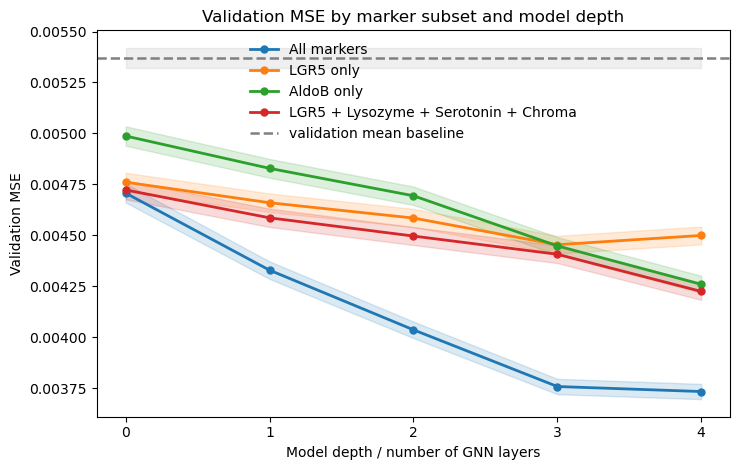

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/marker_subset_depth_comparison/run_20260506_174211/figures/spearman_variance_sqerr_by_marker_subset_and_depth.pdf


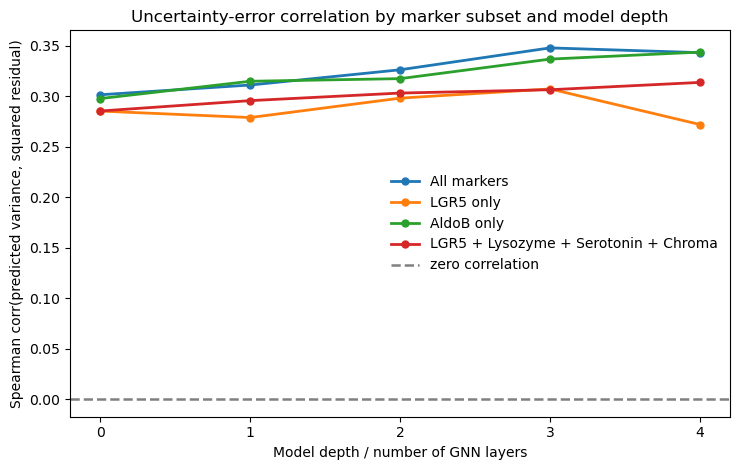

(<Figure size 750x480 with 1 Axes>,
 <Axes: title={'center': 'Uncertainty-error correlation by marker subset and model depth'}, xlabel='Model depth / number of GNN layers', ylabel='Spearman corr(predicted variance, squared residual)'>)

In [56]:
ensure_predicted_variance_available()

# Add variance/correlation summaries if this cell is rerun after an older execution of the prediction cell.
if "mean_pred_var" not in mse_df.columns or "rho_var_sqerr" not in mse_df.columns:
    metric_rows = []
    for variant_name in FEATURE_VARIANTS.keys():
        for depth in DEPTHS:
            pred_pack = predictions_by_variant_depth[(variant_name, int(depth))]
            y_true = np.asarray(pred_pack["y_true"]).reshape(-1)
            y_pred = np.asarray(pred_pack["y_pred"]).reshape(-1)
            pred_var = np.asarray(pred_pack["pred_var"]).reshape(-1)
            sq_err = (y_pred - y_true) ** 2
            rho_var_sqerr, pval_var_sqerr, n_corr = spearman_var_sqerr(pred_var, sq_err)
            metric_rows.append(
                {
                    "variant": variant_name,
                    "depth": int(depth),
                    "mean_pred_var": float(np.mean(pred_var)),
                    "sem_pred_var": float(np.std(pred_var, ddof=1) / np.sqrt(len(pred_var))) if len(pred_var) > 1 else 0.0,
                    "rho_var_sqerr": rho_var_sqerr,
                    "pval_var_sqerr": pval_var_sqerr,
                    "n_corr": n_corr,
                }
            )
    metric_df = pd.DataFrame(metric_rows)
    for col in ["mean_pred_var", "sem_pred_var", "rho_var_sqerr", "pval_var_sqerr", "n_corr"]:
        if col in mse_df.columns:
            mse_df = mse_df.drop(columns=[col])
    mse_df = mse_df.merge(metric_df, on=["variant", "depth"], how="left")

baseline_sq_err = (truth_reference - np.mean(truth_reference)) ** 2
baseline_mse = float(np.mean(baseline_sq_err))
baseline_sem = float(np.std(baseline_sq_err, ddof=1) / np.sqrt(len(baseline_sq_err)))

_plot_depth_metric(
    mse_df,
    "mse",
    "sem",
    "Validation MSE",
    "Validation MSE by marker subset and model depth",
    "validation_mse_by_marker_subset_and_depth",
    baseline=baseline_mse,
    baseline_sem=baseline_sem,
    baseline_label="validation mean baseline",
)

_plot_depth_metric(
    mse_df,
    "rho_var_sqerr",
    None,
    "Spearman corr(predicted variance, squared residual)",
    "Uncertainty-error correlation by marker subset and model depth",
    "spearman_variance_sqerr_by_marker_subset_and_depth",
    baseline=0.0,
    baseline_label="zero correlation",
)

In [ ]:
from src.analysis.prediction_analysis import compute_zero_centered_bin_accuracy


def _bin_accuracy_sem(n_correct, n_valid):
    n_valid = int(n_valid)
    if n_valid <= 1:
        return np.nan
    p = float(n_correct) / float(n_valid)
    return float(np.sqrt(p * (1.0 - p) / n_valid))


def summarize_bin_accuracy_for_mask(mask=None, *, subset_label="all_nodes"):
    mask = None if mask is None else np.asarray(mask, dtype=bool).reshape(-1)
    rows = []

    for variant_name in FEATURE_VARIANTS.keys():
        for depth in DEPTHS:
            pred_pack = predictions_by_variant_depth[(variant_name, int(depth))]
            y_true = np.asarray(pred_pack["y_true"]).reshape(-1)
            y_pred = np.asarray(pred_pack["y_pred"]).reshape(-1)

            node_df, summary = compute_zero_centered_bin_accuracy(
                graphs=feature_data[variant_name]["g_val"],
                y_true=y_true,
                y_pred=y_pred,
                n_bins=5,
                scope="dataset",
                target_index=TARGET_INDEX_FOR_PLOTS,
            )

            if mask is None:
                sub_node_df = node_df
            else:
                if mask.shape[0] != len(node_df):
                    raise ValueError(
                        f"Mask length {mask.shape[0]} does not match validation target length {len(node_df)}."
                    )
                sub_node_df = node_df.loc[mask]

            valid = sub_node_df["valid_bin"].to_numpy(dtype=bool)
            correct = sub_node_df["bin_correct"].to_numpy(dtype=bool)
            n_valid = int(valid.sum())
            n_correct = int((valid & correct).sum())

            rows.append(
                {
                    "subset": subset_label,
                    "variant": variant_name,
                    "variant_label": FEATURE_VARIANT_LABELS.get(variant_name, variant_name),
                    "depth": int(depth),
                    "bin_accuracy": float(n_correct / n_valid) if n_valid else np.nan,
                    "sem": _bin_accuracy_sem(n_correct, n_valid),
                    "n_correct": n_correct,
                    "n_valid": n_valid,
                    "n_nodes": int(len(sub_node_df)),
                }
            )

    return pd.DataFrame(rows).sort_values(["variant", "depth"]).reset_index(drop=True)


bin_accuracy_df = summarize_bin_accuracy_for_mask(None, subset_label="all_nodes")
display(bin_accuracy_df)

_plot_depth_metric(
    bin_accuracy_df,
    "bin_accuracy",
    "sem",
    "Bin accuracy",
    "Dataset-scope bin accuracy by marker subset and model depth",
    "bin_accuracy_by_marker_subset_and_depth",
)


,subset,variant,variant_label,depth,mse,sem,mean_pred_var,sem_pred_var,rho_var_sqerr,pval_var_sqerr,n_corr,n_nodes
0,LGR5_positive,AldoB_only,AldoB only,0,0.005349,0.000097,0.001905,0.000010,0.429107,0.000000e+00,14325,14325
1,LGR5_positive,AldoB_only,AldoB only,1,0.005192,0.000095,0.001864,0.000011,0.429844,0.000000e+00,14325,14325
2,LGR5_positive,AldoB_only,AldoB only,2,0.005091,0.000094,0.001871,0.000011,0.418562,0.000000e+00,14325,14325
3,LGR5_positive,AldoB_only,AldoB only,3,0.004926,0.000091,0.002169,0.000017,0.414019,0.000000e+00,14325,14325
4,LGR5_positive,AldoB_only,AldoB only,4,0.004528,0.000086,0.001967,0.000015,0.391207,0.000000e+00,14325,14325
5,LGR5_positive,LGR5_Lysozyme_Serotonin_Chroma,LGR5 + Lysozyme + Serotonin + Chroma,0,0.004398,0.000089,0.002134,0.000013,0.339880,0.000000e+00,14325,14325
6,LGR5_positive,LGR5_Lysozyme_Serotonin_Chroma,LGR5 + Lysozyme + Serotonin + Chroma,1,0.004119,0.000085,0.002138,0.000014,0.326897,0.000000e+00,14325,14325
7,LGR5_positive,LGR5_Lysozyme_Serotonin_Chroma,LGR5 + Lysozyme + Serotonin + Chroma,2,0.003988,0.000083,0.002058,0.000012,0.295470,1.709774e-286,14325,14325
8,LGR5_positive,LGR5_Lysozyme_Serotonin_Chroma,LGR5 + Lysozyme + Serotonin + Chroma,3,0.003979,0.000082,0.002440,0.000012,0.301002,9.161848e-298,14325,14325
9,LGR5_positive,LGR5_Lysozyme_Serotonin_Chroma,LGR5 + Lysozyme + Serotonin + Chroma,4,0.003767,0.000078,0.002622,0.000020,0.287256,3.271278e-270,14325,14325


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/marker_subset_depth_comparison/run_20260506_174211/figures/validation_mse_lgr5_positive_negative_by_marker_subset_and_depth.pdf


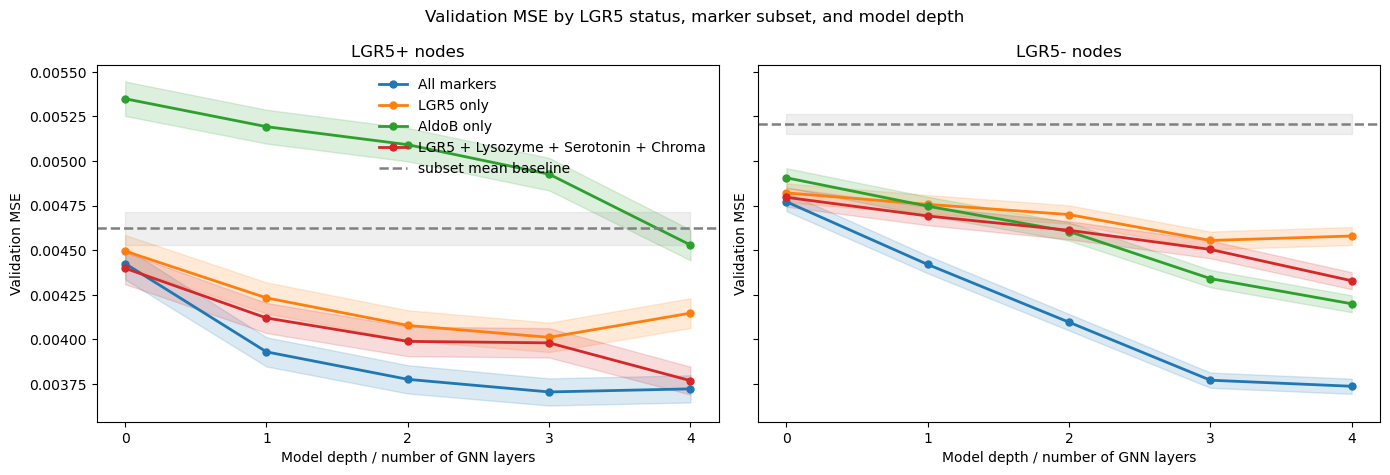

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/marker_subset_depth_comparison/run_20260506_174211/figures/spearman_variance_sqerr_lgr5_positive_negative_by_marker_subset_and_depth.pdf


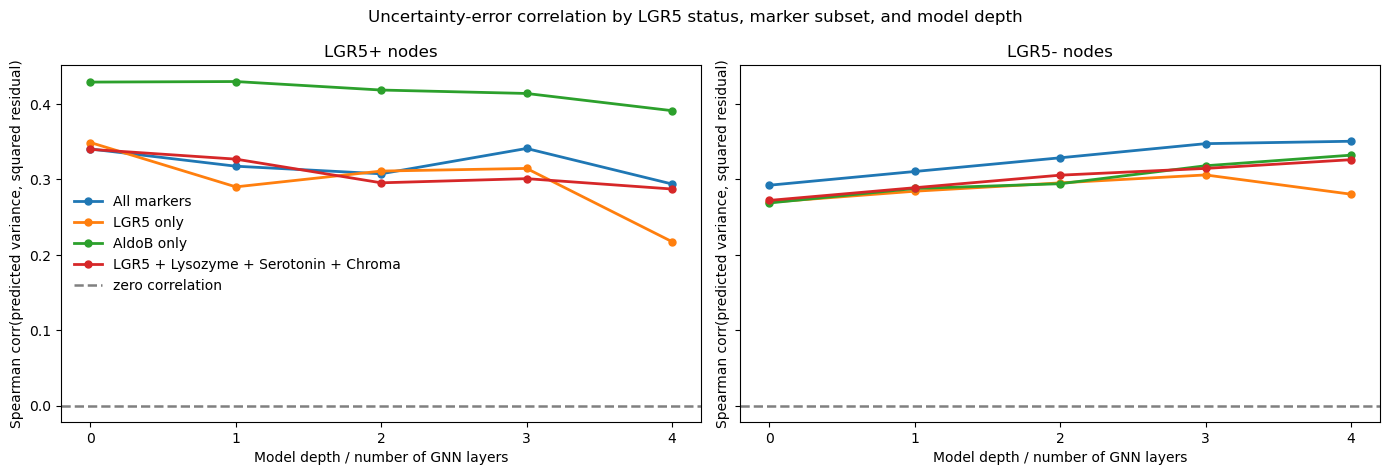

(<Figure size 1400x480 with 2 Axes>,
 array([<Axes: title={'center': 'LGR5+ nodes'}, xlabel='Model depth / number of GNN layers', ylabel='Spearman corr(predicted variance, squared residual)'>,
        <Axes: title={'center': 'LGR5- nodes'}, xlabel='Model depth / number of GNN layers', ylabel='Spearman corr(predicted variance, squared residual)'>],
       dtype=object))

In [57]:
LGR5_MARKER_NAME = "LGR5"
LGR5_POSITIVE_THRESHOLD = 0.5

lgr5_positive_mask = original_marker_positive_mask(LGR5_MARKER_NAME, threshold=LGR5_POSITIVE_THRESHOLD)
lgr5_negative_mask = ~lgr5_positive_mask

lgr5_positive_mse_df = summarize_depth_metrics_for_mask(lgr5_positive_mask, subset_label="LGR5_positive")
lgr5_negative_mse_df = summarize_depth_metrics_for_mask(lgr5_negative_mask, subset_label="LGR5_negative")
lgr5_mse_by_sign_df = pd.concat([lgr5_positive_mse_df, lgr5_negative_mse_df], ignore_index=True)
display(lgr5_mse_by_sign_df)

lgr5_positive_baseline = marker_subset_baseline(lgr5_positive_mask)
lgr5_negative_baseline = marker_subset_baseline(lgr5_negative_mask)

_plot_depth_metric_pair(
    lgr5_positive_mse_df,
    lgr5_negative_mse_df,
    "mse",
    "sem",
    "Validation MSE",
    "LGR5+ nodes",
    "LGR5- nodes",
    "Validation MSE by LGR5 status, marker subset, and model depth",
    "validation_mse_lgr5_positive_negative_by_marker_subset_and_depth",
    left_baseline=lgr5_positive_baseline["mse"],
    left_baseline_sem=lgr5_positive_baseline["sem"],
    right_baseline=lgr5_negative_baseline["mse"],
    right_baseline_sem=lgr5_negative_baseline["sem"],
    baseline_label="subset mean baseline",
)

_plot_depth_metric_pair(
    lgr5_positive_mse_df,
    lgr5_negative_mse_df,
    "rho_var_sqerr",
    None,
    "Spearman corr(predicted variance, squared residual)",
    "LGR5+ nodes",
    "LGR5- nodes",
    "Uncertainty-error correlation by LGR5 status, marker subset, and model depth",
    "spearman_variance_sqerr_lgr5_positive_negative_by_marker_subset_and_depth",
    left_baseline=0.0,
    right_baseline=0.0,
    baseline_label="zero correlation",
)

In [ ]:
lgr5_positive_bin_accuracy_df = summarize_bin_accuracy_for_mask(lgr5_positive_mask, subset_label="LGR5_positive")
lgr5_negative_bin_accuracy_df = summarize_bin_accuracy_for_mask(lgr5_negative_mask, subset_label="LGR5_negative")
lgr5_bin_accuracy_by_sign_df = pd.concat(
    [lgr5_positive_bin_accuracy_df, lgr5_negative_bin_accuracy_df],
    ignore_index=True,
)
display(lgr5_bin_accuracy_by_sign_df)

_plot_depth_metric_pair(
    lgr5_positive_bin_accuracy_df,
    lgr5_negative_bin_accuracy_df,
    "bin_accuracy",
    "sem",
    "Bin accuracy",
    "LGR5+ nodes",
    "LGR5- nodes",
    "Dataset-scope bin accuracy by LGR5 status, marker subset, and model depth",
    "bin_accuracy_lgr5_positive_negative_by_marker_subset_and_depth",
)


,subset,variant,variant_label,depth,mse,sem,mean_pred_var,sem_pred_var,rho_var_sqerr,pval_var_sqerr,n_corr,n_nodes
0,AldoB_positive,AldoB_only,AldoB only,0,0.003930,0.000072,0.001670,0.000006,0.173270,1.013023e-192,28771,28771
1,AldoB_positive,AldoB_only,AldoB only,1,0.003809,0.000070,0.001553,0.000006,0.211480,3.246734e-288,28771,28771
2,AldoB_positive,AldoB_only,AldoB only,2,0.003621,0.000068,0.001605,0.000009,0.234458,0.000000e+00,28771,28771
3,AldoB_positive,AldoB_only,AldoB only,3,0.003291,0.000063,0.001998,0.000020,0.251062,0.000000e+00,28771,28771
4,AldoB_positive,AldoB_only,AldoB only,4,0.003069,0.000060,0.001825,0.000020,0.274806,0.000000e+00,28771,28771
5,AldoB_positive,LGR5_Lysozyme_Serotonin_Chroma,LGR5 + Lysozyme + Serotonin + Chroma,0,0.003956,0.000072,0.001886,0.000005,0.189384,1.646521e-230,28771,28771
6,AldoB_positive,LGR5_Lysozyme_Serotonin_Chroma,LGR5 + Lysozyme + Serotonin + Chroma,1,0.003905,0.000071,0.002006,0.000007,0.206737,3.029428e-275,28771,28771
7,AldoB_positive,LGR5_Lysozyme_Serotonin_Chroma,LGR5 + Lysozyme + Serotonin + Chroma,2,0.003848,0.000070,0.001731,0.000006,0.218608,2.607550e-308,28771,28771
8,AldoB_positive,LGR5_Lysozyme_Serotonin_Chroma,LGR5 + Lysozyme + Serotonin + Chroma,3,0.003729,0.000069,0.001835,0.000009,0.225301,0.000000e+00,28771,28771
9,AldoB_positive,LGR5_Lysozyme_Serotonin_Chroma,LGR5 + Lysozyme + Serotonin + Chroma,4,0.003550,0.000066,0.001662,0.000010,0.240635,0.000000e+00,28771,28771


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/marker_subset_depth_comparison/run_20260506_174211/figures/validation_mse_aldob_positive_negative_by_marker_subset_and_depth.pdf


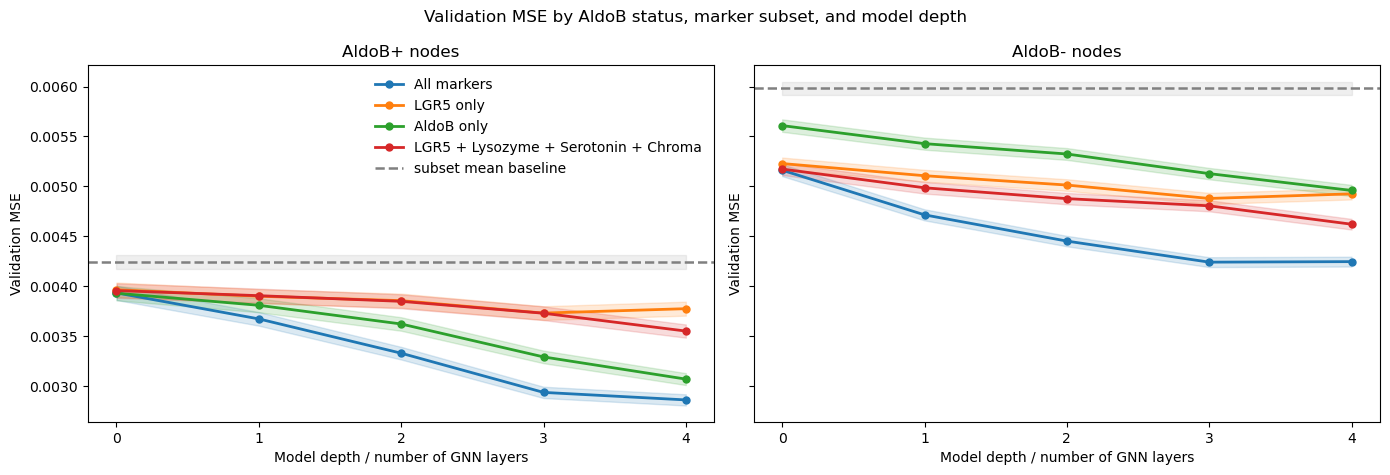

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/marker_subset_depth_comparison/run_20260506_174211/figures/spearman_variance_sqerr_aldob_positive_negative_by_marker_subset_and_depth.pdf


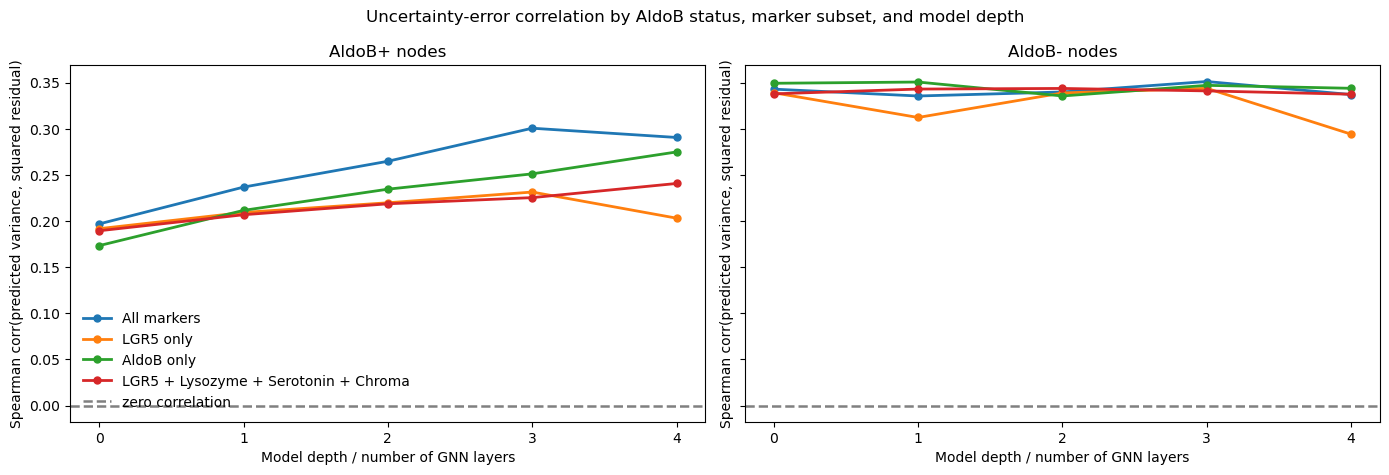

(<Figure size 1400x480 with 2 Axes>,
 array([<Axes: title={'center': 'AldoB+ nodes'}, xlabel='Model depth / number of GNN layers', ylabel='Spearman corr(predicted variance, squared residual)'>,
        <Axes: title={'center': 'AldoB- nodes'}, xlabel='Model depth / number of GNN layers', ylabel='Spearman corr(predicted variance, squared residual)'>],
       dtype=object))

In [58]:
ALDOB_MARKER_NAME = "AldoB"
ALDOB_POSITIVE_THRESHOLD = 0.5

# AldoB is absent from the reduced feature sets, so the all-marker validation X is used as the reference mask.
aldob_positive_mask = original_marker_positive_mask(ALDOB_MARKER_NAME, threshold=ALDOB_POSITIVE_THRESHOLD)
aldob_negative_mask = ~aldob_positive_mask

aldob_positive_mse_df = summarize_depth_metrics_for_mask(aldob_positive_mask, subset_label="AldoB_positive")
aldob_negative_mse_df = summarize_depth_metrics_for_mask(aldob_negative_mask, subset_label="AldoB_negative")
aldob_mse_by_sign_df = pd.concat([aldob_positive_mse_df, aldob_negative_mse_df], ignore_index=True)
display(aldob_mse_by_sign_df)

aldob_positive_baseline = marker_subset_baseline(aldob_positive_mask)
aldob_negative_baseline = marker_subset_baseline(aldob_negative_mask)

_plot_depth_metric_pair(
    aldob_positive_mse_df,
    aldob_negative_mse_df,
    "mse",
    "sem",
    "Validation MSE",
    "AldoB+ nodes",
    "AldoB- nodes",
    "Validation MSE by AldoB status, marker subset, and model depth",
    "validation_mse_aldob_positive_negative_by_marker_subset_and_depth",
    left_baseline=aldob_positive_baseline["mse"],
    left_baseline_sem=aldob_positive_baseline["sem"],
    right_baseline=aldob_negative_baseline["mse"],
    right_baseline_sem=aldob_negative_baseline["sem"],
    baseline_label="subset mean baseline",
)

_plot_depth_metric_pair(
    aldob_positive_mse_df,
    aldob_negative_mse_df,
    "rho_var_sqerr",
    None,
    "Spearman corr(predicted variance, squared residual)",
    "AldoB+ nodes",
    "AldoB- nodes",
    "Uncertainty-error correlation by AldoB status, marker subset, and model depth",
    "spearman_variance_sqerr_aldob_positive_negative_by_marker_subset_and_depth",
    left_baseline=0.0,
    right_baseline=0.0,
    baseline_label="zero correlation",
)

In [ ]:
aldob_positive_bin_accuracy_df = summarize_bin_accuracy_for_mask(aldob_positive_mask, subset_label="AldoB_positive")
aldob_negative_bin_accuracy_df = summarize_bin_accuracy_for_mask(aldob_negative_mask, subset_label="AldoB_negative")
aldob_bin_accuracy_by_sign_df = pd.concat(
    [aldob_positive_bin_accuracy_df, aldob_negative_bin_accuracy_df],
    ignore_index=True,
)
display(aldob_bin_accuracy_by_sign_df)

_plot_depth_metric_pair(
    aldob_positive_bin_accuracy_df,
    aldob_negative_bin_accuracy_df,
    "bin_accuracy",
    "sem",
    "Bin accuracy",
    "AldoB+ nodes",
    "AldoB- nodes",
    "Dataset-scope bin accuracy by AldoB status, marker subset, and model depth",
    "bin_accuracy_aldob_positive_negative_by_marker_subset_and_depth",
)


## Reference Organoid Predictions

In [59]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from organograph.plotting.meshes import plot_organoid_mesh

from src.data.splits import select_graphs_by_keys
from src.plotting.mesh_plots import get_graph_slice_bounds, project_node_quantities_to_mesh

selected_graphs = select_graphs_by_keys(
    g_val,
    FORCED_VAL_KEYS,
    key_fn=graph_metadata_key,
    meta_lookup=val_meta_lookup,
)

if selected_graphs:
    g_ref = selected_graphs[0]
else:
    print("No forced reference organoid found in validation; using the first validation graph.")
    g_ref = g_val[0]

selected_organoid_str = getattr(g_ref, "organoid_str")
graph_index = [
    i for i, gg in enumerate(g_val)
    if getattr(gg, "organoid_str", None) == selected_organoid_str
][0]
start, end = get_graph_slice_bounds(g_val, graph_index)
selected_key = graph_metadata_key(g_ref, meta_lookup=val_meta_lookup)
print("Reference organoid:", selected_key, selected_organoid_str, "node slice", (start, end))

truth_ref = truth_reference[start:end]
all_ref_values = [truth_ref]
for variant_name in FEATURE_VARIANTS:
    for depth in DEPTHS:
        all_ref_values.append(predictions_by_variant_depth[(variant_name, int(depth))]["y_pred"][start:end])
all_ref_values = np.concatenate([np.asarray(v).reshape(-1) for v in all_ref_values])
finite_ref_values = all_ref_values[np.isfinite(all_ref_values)]
abs_max = float(np.max(np.abs(finite_ref_values))) if finite_ref_values.size else 1.0
vmin, vmax = -abs_max, abs_max

Reference organoid: ('20251201', 'day4p5_B03_144') organoid_day4p5_B03_144 node slice (49661, 50962)


In [ ]:
variant_order = list(FEATURE_VARIANTS.keys())
n_rows = len(variant_order)
n_cols = len(DEPTHS) + 1

subplot_titles = []
for variant_name in variant_order:
    label = FEATURE_VARIANT_LABELS.get(variant_name, variant_name)
    subplot_titles.append(f"{label}<br>true")
    for depth in DEPTHS:
        subplot_titles.append(f"{label}<br>depth={depth}")

fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    specs=[[{"type": "scene"} for _ in range(n_cols)] for _ in range(n_rows)],
    subplot_titles=subplot_titles,
    horizontal_spacing=0.01,
    vertical_spacing=0.03,
)

for row, variant_name in enumerate(variant_order, start=1):
    for col, depth_or_true in enumerate(["true"] + list(DEPTHS), start=1):
        if depth_or_true == "true":
            node_pred = truth_ref
            node_true = truth_ref
            values = "mesh_true"
        else:
            node_pred = predictions_by_variant_depth[(variant_name, int(depth_or_true))]["y_pred"][start:end]
            node_true = truth_ref
            values = "mesh_pred"

        proj = project_node_quantities_to_mesh(
            g_ref,
            node_pred=node_pred,
            node_true=node_true,
            target_index=None,
            meta_lookup=val_meta_lookup,
        )
        subfig = plot_organoid_mesh(
            proj["mesh"],
            vertex_values=proj[values],
            backend="plotly",
            colorscale="RdBu_r",
            center_at_zero=True,
            vmin=vmin,
            vmax=vmax,
            show_colorbar=(row == 1 and col == n_cols),
            fig_size=(450, 420),
            view=REFERENCE_VIEW,
        )

        for tr in subfig.data:
            fig.add_trace(tr, row=row, col=col)

        scene_name = "scene" if (row == 1 and col == 1) else f"scene{(row - 1) * n_cols + col}"
        if subfig.layout.scene is not None:
            fig.layout[scene_name].update(subfig.layout.scene.to_plotly_json())

fig.update_layout(
    width=360 * n_cols,
    height=330 * n_rows,
    title=f"Reference organoid predictions by marker subset and depth | {selected_key}",
    margin=dict(l=10, r=10, t=90, b=10),
)

save_plotly_figure(fig, "reference_organoid_predictions_by_marker_subset_and_depth")
fig.show()

## Save Results

In [ ]:
SAVE_DIR.mkdir(parents=True, exist_ok=True)
mse_csv_path = SAVE_DIR / "mse_by_marker_subset_and_depth.csv"
mse_df.to_csv(mse_csv_path, index=False)
print(f"Saved MSE table -> {mse_csv_path}")

spearman_csv_path = SAVE_DIR / "spearman_variance_sqerr_by_marker_subset_and_depth.csv"
mse_df[["variant", "variant_label", "depth", "rho_var_sqerr", "pval_var_sqerr", "n_corr", "n_nodes"]].to_csv(spearman_csv_path, index=False)
print(f"Saved Spearman correlation table -> {spearman_csv_path}")

for table_name, table in {
    "mse_lgr5_positive_by_marker_subset_and_depth.csv": globals().get("lgr5_positive_mse_df"),
    "mse_lgr5_negative_by_marker_subset_and_depth.csv": globals().get("lgr5_negative_mse_df"),
    "mse_aldob_positive_by_marker_subset_and_depth.csv": globals().get("aldob_positive_mse_df"),
    "mse_aldob_negative_by_marker_subset_and_depth.csv": globals().get("aldob_negative_mse_df"),
}.items():
    if table is not None:
        table_path = SAVE_DIR / table_name
        table.to_csv(table_path, index=False)
        print(f"Saved subset table -> {table_path}")



for table_name, table in {
    "bin_accuracy_by_marker_subset_and_depth.csv": globals().get("bin_accuracy_df"),
    "bin_accuracy_lgr5_positive_by_marker_subset_and_depth.csv": globals().get("lgr5_positive_bin_accuracy_df"),
    "bin_accuracy_lgr5_negative_by_marker_subset_and_depth.csv": globals().get("lgr5_negative_bin_accuracy_df"),
    "bin_accuracy_aldob_positive_by_marker_subset_and_depth.csv": globals().get("aldob_positive_bin_accuracy_df"),
    "bin_accuracy_aldob_negative_by_marker_subset_and_depth.csv": globals().get("aldob_negative_bin_accuracy_df"),
}.items():
    if table is not None:
        table_path = SAVE_DIR / table_name
        table.to_csv(table_path, index=False)
        print(f"Saved bin accuracy table -> {table_path}")

config = {
    "dataset_name": DATASET_NAME,
    "target_indices": TARGET_INDICES,
    "target_index_for_plots": TARGET_INDEX_FOR_PLOTS,
    "use_global_features": USE_GLOBAL_FEATURES,
    "filtering": {
        "missing_complexity_group": MISSING_COMPLEXITY_GROUP,
        "sphericity_max": SPHERICITY_MAX,
        "spherical_marker_diversity_min": SPHERICAL_MARKER_DIVERSITY_MIN,
        "complexity_min": COMPLEXITY_MIN,
        "interpolate_target_outliers": INTERPOLATE_TARGET_OUTLIERS,
        "outlier_clip_quantiles": OUTLIER_CLIP_QUANTILES,
        "outlier_info": outlier_info,
    },
    "split": split_info,
    "feature_variants": FEATURE_VARIANTS,
    "feature_variant_labels": FEATURE_VARIANT_LABELS,
    "depths": DEPTHS,
    "model": {
        "model_class": "GINCurvature",
        "hidden_dim": HIDDEN_DIM,
        "dropout": DROPOUT,
        "norm": NORM,
        "residual": RESIDUAL,
        "global_dim": global_dim,
    },
    "training": {
        "lr": LR,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "num_workers": NUM_WORKERS,
        "edge_loss_weight": EDGE_LOSS_WEIGHT,
        "edge_loss_params": EDGE_LOSS_PARAMS,
    },
    "marker_names": marker_names,
    "variant_marker_names": {name: pack["marker_names"] for name, pack in feature_data.items()},
    "global_feature_center": center_global,
    "global_feature_scale": scale_global,
    "save_dir": SAVE_DIR,
    "figures_dir": FIGURES_DIR,
}

results_by_experiment = {
    "mse_table": mse_df,
    "subset_tables": {
        "lgr5_positive": globals().get("lgr5_positive_mse_df"),
        "lgr5_negative": globals().get("lgr5_negative_mse_df"),
        "aldob_positive": globals().get("aldob_positive_mse_df"),
        "aldob_negative": globals().get("aldob_negative_mse_df"),
    },
    "bin_accuracy_tables": {
        "overall": globals().get("bin_accuracy_df"),
        "lgr5_positive": globals().get("lgr5_positive_bin_accuracy_df"),
        "lgr5_negative": globals().get("lgr5_negative_bin_accuracy_df"),
        "aldob_positive": globals().get("aldob_positive_bin_accuracy_df"),
        "aldob_negative": globals().get("aldob_negative_bin_accuracy_df"),
    },
    "baseline": {
        "mse": baseline_mse,
        "sem": baseline_sem,
        "n_nodes": int(len(truth_reference)),
    },
    "predictions_by_variant_depth": predictions_by_variant_depth,
    "training_logs": training_logs,
    "reference_organoid": {
        "key": selected_key,
        "organoid_str": selected_organoid_str,
        "graph_index": int(graph_index),
        "node_slice": (int(start), int(end)),
    },
}

save_joint_experiment(
    SAVE_DIR,
    config=config,
    results_by_experiment=results_by_experiment,
    notes="Depth scan comparing all markers, LGR5 only, and LGR5/Lysozyme/Serotonin/Chroma marker subsets.",
)